# Linear Regression Project

Performing Linear Regression, beginning to end on a dataset of your choice.

---
## Part 1: Data Scoping

10 pts

**Describe this data:**
Breifly describe, what is this data about? Where is it from?

Ocean water-quality monitoring data from the Surfrider Foundation's Blue Water Task Force in Oahu. Citizens sample seawater at specifc cites biweekly and a lab measures enterococcus, a species of bacteria.

**URL:** https://bwtf.surfrider.org/report/44

**Attribution** and/or License:
Surfrider Foundation, Blue Water Task Force (Oʻahu chapter), report 44
Answer these following questions:


*   What is one row in this dataset? Be specific about who, when, where, etc. Is this a real or simulated dataset?

One row is a single water sample: sample_id, date, enteroccocus, ent_modifier, unsafe, etc. This is real data.

*   What is the target variable `y` (including units)?

The label our classifer predicts as unsafe or not.

*   Does your target variable `y` depend on your feature columns `X`?

Sort of, rainfall drives runoff into the sea, so weather features might cause bacterial spike.

*   What population does this dataset represent? Who may have been left out?

The filtered one represents nearshore ocean water at 9 popular oahu swim beaches.

*   Who would be potential user of this model? What decision might this model help them make?

Beachgoers, surfers, and familes wanting to swim.

*   Are there any potential misuses of this model? "This model should not be used for..."

It should not be u sed for official water quality determinations, and it shall not displace DOH/ brown water alerts.


---
## Part 2: Exploratory Data Analysis (EDA)

10 pts

Understand, summarize, and visualize your data.

*   **Find data errors:** Spot missing values, duplicate entries, and incorrect data types early. Which columns are non-numerical?
*   **Detect outliers:** Catch extreme values or anomalies that can ruin statistical or machine learning models.
*   **Understand distributions:** Check if numerical data is normal, skewed, or spread out using summary stats and charts. Are there any columns which need to be scaled?
*   **Reveal relationships:** Find correlations and hidden connections between different variables using heatmaps or scatter plots. Remove any columns which are highly correlated with each other.


If you have a large number of feature columns `x_1`, `x_2`, ... `x_n`, you may want to select 5-15 of them focus on, though be sure to explain how reducing the number of features will impact your model.

In [6]:
from google.colab import files
uploaded = files.upload()   # upload surfrider_raw.csv

Saving surfrider_raw.csv to surfrider_raw.csv


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("surfrider_raw.csv")
print(df.shape)
df.head()

(3713, 38)


,sample id,data entry author,state,lab id,lab name,collection date,collection time (Pacific/Honolulu),stored collectionTime,tested by,site id,...,pH,Salinity (PSU),Turbidity (NTU),Ammonia/NH3 (ppm),Nitrates/NO3 (mg/L),Nitrites/NO2 (mg/L),Nitrogen(NO3+NO2) (mg/L),Phosphate (mg/L),Dissolved Oxygen (mg/L),publication time
0,baccff0c-016f-4be9-aaa2-602e12b820e6,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:10:00 AM,2026-09-06T19:10:00.000Z,Karen G,1195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:08:15.725Z
1,f60244e6-3c6f-4357-aa20-61a278577347,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:10:00 AM,2026-09-06T19:10:00.000Z,Rossoff,859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:27:41.702Z
2,d7ac771c-10eb-4761-a222-7ed87f5d5d6c,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:00:00 AM,2026-09-06T19:00:00.000Z,Greg Young,858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:21:59.451Z
3,3a827787-cee0-4294-8189-a9c8e9245e6b,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,8:59:00 AM,2026-09-06T18:59:00.000Z,Ian M,979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:02:14.853Z
4,ecb8b575-bcfd-4f9c-b8d8-1a2c128e29df,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,8:50:00 AM,2026-09-06T18:50:00.000Z,Karen G,1197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:09:58.004Z


In [8]:
# --- 2.1 Structure & data types: which columns are non-numerical? ---
print(df.dtypes)
non_numeric = df.select_dtypes(exclude="number").columns.tolist()
print("\nNon-numeric columns:", non_numeric)
# sample id / site name / modifiers / dates are text or codes, not quantities.

sample id                              object
data entry author                      object
state                                  object
lab id                                  int64
lab name                               object
collection date                        object
collection time (Pacific/Honolulu)     object
stored collectionTime                  object
tested by                              object
site id                                 int64
site name                              object
latitude                              float64
longitude                             float64
water temperature (f)                 float64
air temperature (f)                   float64
current weather                        object
recent precipitation                   object
tide                                   object
wave height                            object
wind speed (mph)                      float64
wind direction                         object
Enterococcus modifier             

In [ ]:
# --- 2.2 Missing values: how much, and does 'missing' mean unknown or none? ---
miss = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
print(miss[miss > 0])
# Reading: the lab chemistry columns (pH, Salinity, Turbidity, Nitrates...) are
# almost entirely blank -> those tests were simply not run, not "unknown".
# The one column we actually need, 'Enterococcus (mpn/100mL)', is ~0.4% missing.

Phosphate (mg/L)              100.0
Nitrogen(NO3+NO2) (mg/L)      100.0
Nitrites/NO2 (mg/L)           100.0
Nitrates/NO3 (mg/L)           100.0
Ammonia/NH3 (ppm)             100.0
Turbidity (NTU)               100.0
Dissolved Oxygen (mg/L)       100.0
pH                            100.0
Ecoli (mpn/100mL)              99.8
Ecoli modifier                 99.8
Total Coliform (mpn/100mL)     99.6
Total Coliform modifier        99.6
Salinity (PSU)                 79.8
comments                       49.3
wind speed (mph)               29.2
wind direction                 25.1
water temperature (f)          24.8
air temperature (f)            10.2
wave height                     6.8
current weather                 5.1
recent precipitation            4.4
tide                            2.0
Enterococcus modifier           1.1
Enterococcus (mpn/100mL)        0.4
dtype: float64


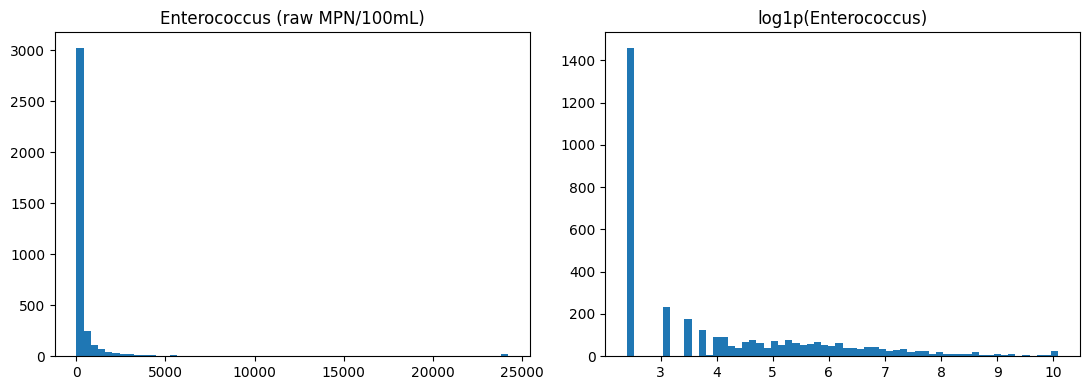

count     3697.000000
mean       619.552340
std       2495.797529
min         10.000000
25%         10.000000
50%         31.000000
75%        231.000000
max      24196.000000
Name: Enterococcus (mpn/100mL), dtype: float64

Share above the 130 MPN/100mL safety threshold: 33.0 %


In [ ]:
# --- 2.3 Target distribution: enterococcus is heavily right-skewed ---
ent = pd.to_numeric(df["Enterococcus (mpn/100mL)"], errors="coerce").dropna()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ent, bins=60);           ax[0].set_title("Enterococcus (raw MPN/100mL)")
ax[1].hist(np.log1p(ent), bins=60); ax[1].set_title("log1p(Enterococcus)")
plt.tight_layout(); plt.show()
print(ent.describe())
print("\nShare above the 130 MPN/100mL safety threshold:",
      round((ent > 130).mean() * 100, 1), "%")
# Raw counts span 4+ orders of magnitude -> a log transform is the natural scale.

In [ ]:
# --- 2.4 Outliers: state the rule (IQR) but interpret with domain sense ---
q1, q3 = ent.quantile([0.25, 0.75]); iqr = q3 - q1
hi = q3 + 1.5 * iqr
print(f"IQR upper fence = {hi:.0f}; {int((ent > hi).sum())} samples above it")
# These are NOT data errors: bacteria genuinely spike into the thousands after
# storm runoff. They're rare-but-real, and they're exactly the events we care
# about -> we keep them (and model on the log scale) rather than capping.

IQR upper fence = 562; 548 samples above it


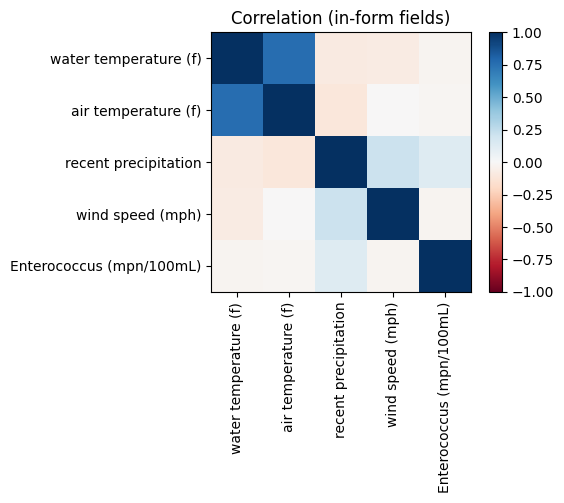

In [ ]:
# --- 2.5 Relationships among the (few) populated numeric env columns ---
env = ["water temperature (f)", "air temperature (f)", "recent precipitation",
       "wind speed (mph)", "Enterococcus (mpn/100mL)"]
num = df[env].apply(pd.to_numeric, errors="coerce")
corr = num.corr()
plt.figure(figsize=(6, 5)); plt.imshow(corr, vmin=-1, vmax=1, cmap="copper" if False else "RdBu")
plt.xticks(range(len(env)), env, rotation=90); plt.yticks(range(len(env)), env)
plt.colorbar(); plt.title("Correlation (in-form fields)"); plt.tight_layout(); plt.show()
# The in-form weather fields are sparse and inconsistent, which motivates Part 4:
# we replace them with a clean, gap-free weather history from Open-Meteo.

---
## Part 3: Data Cleaning

20 pts

### 3a · Duplicates
*   How many rows are exact duplicates of another row?
*   Are they two real records that happen to match, or one record entered twice? These are different, and which one it is determines what you do.

### 3b · Missing values
*   Which columns have missing values, and what percent?
    *   For each one: does missing mean unknown, or does it mean none? Examples: A blank pool-quality column in a housing dataset usually means there is no pool. A blank income column usually means nobody recorded it. Filling the first with an average would be wrong.
*   For each column, pick one: drop the column, drop the rows, or fill in a value.
    *   If you filled in a value, what value, and what does that choice assume about the rows you filled?
    *   Does missingness itself relate to y? If the rows with missing data have a different average y than the rows without, dropping them changes your sample.
### 3c · Outliers
*   Which values are extreme? State the rule you used to decide — IQR, standard deviations, or a domain reason.
    *   For each: Was this outlier a data error, a rare-but-real case, or a code standing in for something else? A negative number in a column measuring a physical quantity is not a small value. It means something. Find out what.
    *   Keep, cap, transform, or remove — and explain why.

In [ ]:
# --- 3a Duplicates ---
print("Exact duplicate rows:", df.duplicated().sum())               # -> 0
print("Duplicate sample ids:", df["sample id"].duplicated().sum())  # -> 0
# No duplicates to resolve. Each row is one lab result for one site on one day.

Exact duplicate rows: 0
Duplicate sample ids: 0


In [ ]:
# --- 3b Missing values: the decision per column ---
# The chemistry columns are >95% empty and irrelevant to swim safety -> DROP them
# by simply not selecting them. The target, enterococcus, is missing on 16 rows;
# a water sample with no bacteria reading tells us nothing -> DROP those rows.
keep = {
    "sample id": "sample_id", "site id": "site_id", "site name": "site_name",
    "latitude": "latitude", "longitude": "longitude", "collection date": "date",
    "stored collectionTime": "datetime_utc",
    "Enterococcus (mpn/100mL)": "enterococcus", "Enterococcus modifier": "ent_modifier",
}
samples = df[list(keep)].rename(columns=keep)
samples = samples[samples["enterococcus"].notna()].copy()

In [ ]:
# --- 3c Outliers + typing + label ---
# The modifier column ('<', '=', '>') flags below/above detection limits. The
# reported number is still the lab's best value, so we keep it as the count and
# keep the modifier as a separate flag rather than discarding these rows.
samples["enterococcus"] = pd.to_numeric(samples["enterococcus"], errors="coerce").astype(int)
samples["date"]         = pd.to_datetime(samples["date"], format="mixed").dt.strftime("%Y-%m-%d")
samples["datetime_utc"] = samples["datetime_utc"]          # kept verbatim (ISO-8601 UTC)
samples["unsafe"]       = (samples["enterococcus"] > 130).astype(int)   # Hawaii DOH standard

samples = samples[["sample_id","site_id","site_name","latitude","longitude",
                   "date","datetime_utc","enterococcus","ent_modifier","unsafe"]]
samples.to_csv("samples.csv", index=False)
print(samples.shape, "| unsafe rate:", round(samples.unsafe.mean()*100, 1), "%")
# ~3697 rows on the current export (3678 in the committed file predates the newest batch).

(3697, 10) | unsafe rate: 33.0 %


---
## Part 4: Data Engineering

25 pts

### 4a · Encode the categorical columns
*   Which columns hold text or codes rather than quantities?
    *   For each: nominal (no order — colors, regions, brands) or ordinal (ordered — poor/fair/good, income bands)?
    *   Nominal → one-hot encode. How many columns does that add?
    *   Ordinal → integer codes. State the spacing you are assuming is equal, and say whether you believe it. Is the gap from "fair" to "good" really the same size as "good" to "excellent"?
    *   Binary → 0 and 1.
    *   More than about 20 distinct values? One-hot encoding adds that many columns. Decide what to do: group the rare levels, use only the top few, or drop the column.

Warning: after one-hot encoding, drop one level from each group ("dummy variable"). If you keep all of them, those columns add up to your intercept's column of ones, your feature matrix becomes singular, and gradient descent will wander without converging.

### 4b · Scale
*   Print the range of every column after cleaning and encoding.
*   Pick a scaling method and apply it. Say why you chose it and why not the alternatives.
*   Write down the numbers your scaler computed. Store the mean and standard deviation of each column in a variable and keep it. If you ever wanted to predict for a new row, you would have to apply these same numbers to it, and a model whose scaling parameters have been lost cannot be used on anything new.
*   One-hot columns are already 0/1. Decide whether to scale them too, and justify it.

### 4c · Build at least one new feature
*   Create a new feature column
*   State the reason for the feature before you build it.
    *   Example: "I think the effect of BMI on cost is different for smokers than non-smokers, so I am building their product" is a reason. "It improved R²" is not a reason, it is a result.
*   Is your feature computed from y, directly or indirectly? A price-per-square-foot feature used to predict price cannot be computed for a house whose price you do not know. If you could not calculate this feature for a brand new row, it does not belong in your model.
*   Is your new feature an exact combination of columns you already have? a, b, and a + b cannot all be in the matrix.

At the end of this section, you should have two dataframes `X_train_A` which does not include your created feature, and `X_train_B` which does include your custom feature - we will use both.

In [ ]:
# --- 4.1 Filter to the swim-beach training scope: 9 sites, 2018 onward ---
BEACH_SITE_IDS = [858, 859, 776, 861, 777, 8894, 780, 1197, 8916]
samples["year"] = samples["date"].str[:4].astype(int)
samples_beaches = (samples[samples.site_id.isin(BEACH_SITE_IDS) & (samples.year >= 2018)]
                   .drop(columns="year").reset_index(drop=True))
samples_beaches.to_csv("samples_beaches.csv", index=False)
print(samples_beaches.shape, "| unsafe:", round(samples_beaches.unsafe.mean()*100, 1), "%")

(1273, 10) | unsafe: 30.0 %


In [ ]:
# --- 4.2 Parse the two-section Open-Meteo file into one daily table ---
import io
lines = open("weather.csv", encoding="utf-8").read().splitlines()
blank = lines.index("")                       # metadata block, blank line, then the daily series
daily = pd.read_csv(io.StringIO("\n".join(lines[blank + 1:])))
daily.columns = [c.split(" (")[0] for c in daily.columns]   # 'rain_sum (mm)' -> 'rain_sum'
daily = daily.rename(columns={"rain_sum": "rain", "temperature_2m_mean": "temp",
                              "wind_speed_10m_max": "wind"})
daily["time"] = pd.to_datetime(daily["time"])
daily = daily.sort_values(["location_id", "time"]).reset_index(drop=True)

# Precompute a "consecutive dry days" streak per location (dry = rain < 1 mm).
daily["dry"]        = daily["rain"] < 1.0
daily["_grp"]       = (~daily["dry"]).groupby(daily.location_id).cumsum()   # new block after each rainy day
daily["dry_streak"] = daily.groupby(["location_id", "_grp"]).cumcount()     # 0 on rainy day, 1,2,... when dry
by_loc = {lid: g.set_index("time").sort_index() for lid, g in daily.groupby("location_id")}

In [ ]:
# --- 4.3 Join weather to each sample, strictly from days up to the sample date ---
# Each beach is matched to its nearest Open-Meteo grid cell (fixed lookup; a couple
# of North-shore beaches share a cell). This is where the no-leakage rule lives:
# every feature uses only the sample day and the days before it.
SITE_TO_LOC = {858: 2, 859: 3, 776: 4, 861: 5, 777: 0, 8894: 1, 780: 6, 1197: 6, 8916: 8}

def weather_features(site_id, date):
    g   = by_loc[SITE_TO_LOC[int(site_id)]]
    d   = pd.Timestamp(date)
    ym1 = d - pd.Timedelta(days=1)
    same = g.loc[d] if d in g.index else None
    prev7 = g.loc[d - pd.Timedelta(days=7): ym1]           # the 7 days before the sample
    return pd.Series({
        "rain_same_day":   same.rain if same is not None else np.nan,
        "rain_prev_7days": round(prev7.rain.sum(), 1),
        "days_since_rain": float(g.loc[ym1, "dry_streak"]) if ym1 in g.index else np.nan,
        "temp_mean":       same.temp if same is not None else np.nan,
        "wind_max":        same.wind if same is not None else np.nan,
    })

feats = samples_beaches.apply(lambda r: weather_features(r.site_id, r.date), axis=1)
samples_beaches_weather = pd.concat([samples_beaches, feats], axis=1)
samples_beaches_weather.to_csv("samples_beaches_weather.csv", index=False)
samples_beaches_weather.head()

,sample_id,site_id,site_name,latitude,longitude,date,datetime_utc,enterococcus,ent_modifier,unsafe,rain_same_day,rain_prev_7days,days_since_rain,temp_mean,wind_max
0,f60244e6-3c6f-4357-aa20-61a278577347,859,South Oʻahu: Magic Island Canoe Launch,21.287770,-157.844116,2026-09-06,2026-09-06T19:10:00.000Z,4611,=,1,6.4,11.2,0.0,26.3,20.0
1,d7ac771c-10eb-4761-a222-7ed87f5d5d6c,858,South Oʻahu: Magic Island Bowls,21.282953,-157.845657,2026-09-06,2026-09-06T19:00:00.000Z,327,=,1,6.4,11.2,0.0,26.3,20.0
2,ecb8b575-bcfd-4f9c-b8d8-1a2c128e29df,1197,North Oʻahu: Kaiaka Bay,21.590278,-158.119167,2026-09-06,2026-09-06T18:50:00.000Z,20,=,0,5.0,24.1,0.0,25.3,22.4
3,11d28250-2e4d-449e-a8b2-c937e99addf0,780,North Oʻahu: Pūpūkea tidepools,21.649846,-158.062988,2026-09-06,2026-09-06T18:00:00.000Z,98,=,0,5.0,24.1,0.0,25.3,22.4
4,5cd0965b-db92-46ad-a094-c11aa7cddb79,8894,East Oʻahu: Kailua Beach Park,21.397806,-157.726000,2026-09-06,2026-09-06T17:00:00.000Z,20,=,0,11.8,40.5,0.0,25.3,20.9


In [ ]:
# --- 4.4 Per-beach reference table (beaches.csv) ---
# The numeric columns are aggregated here; the descriptive ones (beach_name, region,
# full_site_name) are editorial labels, so they live in a small hand-kept lookup.
sb = samples_beaches.copy(); sb["year"] = sb.date.str[:4].astype(int)
agg = (sb.groupby("site_id")
         .agg(latitude=("latitude", "first"), longitude=("longitude", "first"),
              n_samples=("unsafe", "size"), n_unsafe=("unsafe", "sum"),
              first_year=("year", "min"), last_year=("year", "max"))
         .reset_index())
agg["unsafe_pct"] = (agg.n_unsafe / agg.n_samples * 100).round(1)
# merge with the curated labels (beach_name, region, full_site_name) to rebuild beaches.csv
print(agg)

In [ ]:
# --- 4.5 For the linear-regression model that follows (encode + scale + engineered feature) ---
# Target y = log1p(enterococcus)  (Part 2 showed the raw counts are ~log-normal).
# 4a Encode: site_id is nominal -> one-hot, dropping one level to avoid the dummy trap.
# 4b Scale : standardize the continuous weather columns; keep the 0/1 site dummies unscaled.
# 4c New feature: rain_prev_7days is itself an engineered antecedent-rainfall feature
#     (computable for any future row from weather alone -> no leakage). X_train_A omits it,
#     X_train_B includes it, per the Part 4 instructions.
model_df = samples_beaches_weather.dropna(
    subset=["rain_same_day","rain_prev_7days","days_since_rain","temp_mean","wind_max"]).copy()
model_df["y"] = np.log1p(model_df["enterococcus"])
X = pd.get_dummies(model_df[["site_id"]].astype(str), drop_first=True)
cont = ["rain_same_day","days_since_rain","temp_mean","wind_max"]     # A: without rain_prev_7days
X_train_A = pd.concat([X, model_df[cont]], axis=1)
X_train_B = pd.concat([X, model_df[cont + ["rain_prev_7days"]]], axis=1)  # B: adds the engineered feature
# Standardize continuous cols; STORE the mean/std so you can score new rows later (Part 4b).
scale_cols = cont + ["rain_prev_7days"]
mu, sigma = model_df[scale_cols].mean(), model_df[scale_cols].std()
for Xt in (X_train_A, X_train_B):
    for c in [c for c in scale_cols if c in Xt]:
        Xt[c] = (Xt[c] - mu[c]) / sigma[c]
print("X_train_A:", X_train_A.shape, "| X_train_B:", X_train_B.shape)

---
## Part 5: Gradient Descent

25 pts

Write your gradient descent functions

In [ ]:
def compute_cost(X, y, w, b):
    """X (m,n), y (m,), w (n,), b float -> float"""

def compute_gradient(X, y, w, b):
    """-> dj_dw (n,), dj_db (float)"""

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """-> w (n,), b (float), J_history (list)"""

Changes from the previous univariate version:

- `w` is now an array of length `n`, is greater than 1
- `f = X @ w + b` predicts all `m` rows at once
- `dj_dw` is an array of length `n`: `X.T @ (f - y) / m`
- `dj_db` is still one number: `(f - y).mean()`

---
## Part 6: Building the models

Build three models: `baseline` (define what your baseline means), a model build using `X_train_A`, and another model using `X_train_B`.



---
## Part 7: Model evaluation

10 pts

Compare models and report weights in real units (not scaled versions).

| model    | features              | J | cost removed vs baseline |
|----------|-----------------------|---|--------------------------|
| Baseline | none                  |   | 0.0000                   |
| Model A  | original only         |   |                          |
| Model B  | original + engineered |   |                          |

where `cost removed = 1 - J / baseline_J`.


1. **Did Model A beat the baseline?** By how much, in the units of `y`?
2. **Did Model B beat Model A?**
3. **Could question 2 have come out the other way?** Think carefully before answering.
4. **Compare your Part 2 ranking to your fitted weights.** Which features did you expect to matter that did not? Which mattered that you did not expect? Do not edit your Step 2 answer.

**Report the weights** with their real units. "One additional bedroom is associated with a price $32,904 lower, among houses of the same size" is a result. "w_3 = -32.9" is not.